In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from scipy.optimize import minimize

from cartpole import CartPole

jax.config.update("jax_enable_x64", True)

RUN_MODE = "full"    # change to "full" for final runs
SEED = 492
rng = np.random.default_rng(SEED)

OUT_DIR = Path("sf3_week3_task32_true_policy")
FIG_DIR = OUT_DIR / "figures"
LOG_DIR = OUT_DIR / "logs"
for d in [OUT_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if RUN_MODE == "quick":
    HORIZON_NEAR = 60
    HORIZON_DOWN = 90
    GRID_N = 25
    RANDOM_RESTARTS = 3
    MAXITER = 60
else:
    HORIZON_NEAR = 80
    HORIZON_DOWN = 130
    GRID_N = 41
    RANDOM_RESTARTS = 8
    MAXITER = 140

print(f"RUN_MODE={RUN_MODE}, near horizon={HORIZON_NEAR}, downward horizon={HORIZON_DOWN}")

RUN_MODE=full, near horizon=80, downward horizon=130


In [4]:
# Constants copied from cartpole.py
SIM_STEPS = 50
DELTA_TIME = 0.1
POLE_LENGTH = 0.5
POLE_MASS = 0.5
CART_MASS = 0.5
MU_C = 0.001
MU_P = 0.001
GRAVITY = 9.8
MAX_FORCE = 20.0


def wrap_angle(theta):
    return (theta + jnp.pi) % (2.0 * jnp.pi) - jnp.pi


def effective_force(action, max_force=MAX_FORCE):
    return max_force * np.tanh(action / max_force)


def cartpole_step_jax(state, action, max_force=MAX_FORCE):
    """One performAction(action) call, implemented in JAX."""
    force = max_force * jnp.tanh(action / max_force)
    dt = DELTA_TIME / SIM_STEPS

    def inner_step(s, _):
        x, x_dot, theta, theta_dot = s
        sin_theta = jnp.sin(theta)
        cos_theta = jnp.cos(theta)
        m = 4.0 * (CART_MASS + POLE_MASS) - 3.0 * POLE_MASS * (cos_theta ** 2)

        cart_accel = (
            2.0 * (POLE_LENGTH * POLE_MASS * (theta_dot ** 2) * sin_theta + 2.0 * (force - MU_C * x_dot))
            - 3.0 * POLE_MASS * GRAVITY * cos_theta * sin_theta
            + 6.0 * MU_P * theta_dot * cos_theta / POLE_LENGTH
        ) / m

        pole_accel = (
            -3.0 * cos_theta * (2.0 / POLE_LENGTH)
            * (POLE_LENGTH / 2.0 * POLE_MASS * (theta_dot ** 2) * sin_theta + force - MU_C * x_dot)
            + 6.0 * (CART_MASS + POLE_MASS) / (POLE_MASS * POLE_LENGTH)
            * (POLE_MASS * GRAVITY * sin_theta - 2.0 / POLE_LENGTH * MU_P * theta_dot)
        ) / m

        x_dot_new = x_dot + dt * cart_accel
        theta_dot_new = theta_dot + dt * pole_accel
        theta_new = theta + dt * theta_dot_new
        x_new = x + dt * x_dot_new
        return jnp.array([x_new, x_dot_new, theta_new, theta_dot_new]), None

    state_new, _ = jax.lax.scan(inner_step, state, None, length=SIM_STEPS)
    return state_new

In [6]:
check_state = np.array([0.2, -0.4, 0.3, 1.1])
check_action = 7.5

system = CartPole(visual=False)
system.setState(check_state.copy())
system.performAction(check_action)
next_np = system.getState()

next_jax = np.array(cartpole_step_jax(jnp.asarray(check_state), check_action))
print("CartPole step:", next_np)
print("JAX step:    ", next_jax)
print("norm diff:   ", np.linalg.norm(next_np - next_jax))

CartPole step: [ 0.20685199  0.51455298  0.32391388 -0.56049053]
JAX step:     [ 0.20685199  0.51455298  0.32391388 -0.56049053]
norm diff:    0.0


In [8]:
def policy_action(p, state):
    x, x_dot, theta, theta_dot = state
    features = jnp.array([x, x_dot, wrap_angle(theta), theta_dot])
    return jnp.dot(p, features)


def point_loss(state, sigmas):
    x, x_dot, theta, theta_dot = state
    err = jnp.array([x, x_dot, wrap_angle(theta), theta_dot]) / sigmas
    return 1.0 - jnp.exp(-0.5 * jnp.sum(err ** 2))


def rollout_loss(p, init_state, horizon, sigmas, effort_weight=0.002, max_force=MAX_FORCE):
    """Mean trajectory loss under the true dynamics."""
    def body(state, _):
        action = policy_action(p, state)
        next_state = cartpole_step_jax(state, action, max_force=max_force)
        force_fraction = jnp.tanh(action / max_force)
        loss_t = point_loss(next_state, sigmas) + effort_weight * force_fraction ** 2
        return next_state, loss_t

    _, losses = jax.lax.scan(body, init_state, None, length=horizon)
    return jnp.mean(losses)


# horizon, effort_weight and max_force must be static because they set scan lengths/control flow.
loss_value = jax.jit(rollout_loss, static_argnums=(2, 4, 5))
loss_and_grad = jax.jit(jax.value_and_grad(rollout_loss), static_argnums=(2, 4, 5))

## Loss scans before optimisation

The scan below varies two coefficients of the policy, $p_\theta$ and $p_{\dot\theta}$, while setting $p_x=p_{\dot{x}}=0$. This is deliberately not the final optimisation; it is just a visual check that the loss landscape is nontrivial and that some feedback signs are better than others.

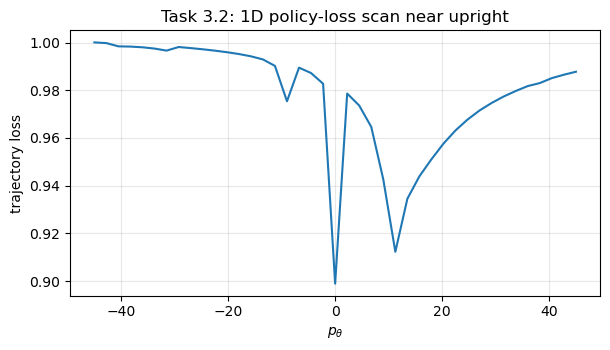

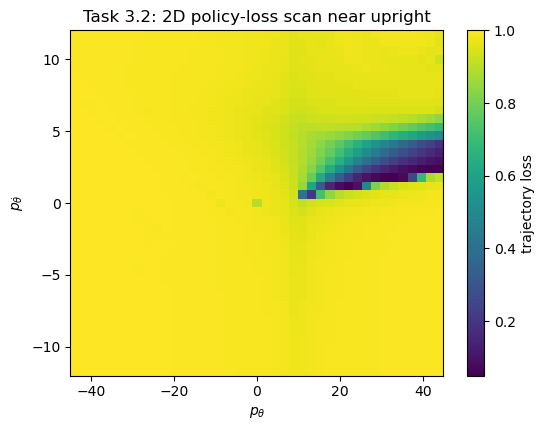

In [10]:
near_init = np.array([0.0, 0.0, 0.20, 0.0])      # slightly displaced from upright
near_sigmas = np.array([1.0, 2.0, 0.45, 3.0])    # [x, x_dot, theta, theta_dot]

p_theta_values = np.linspace(-45, 45, GRID_N)
p_omega_values = np.linspace(-12, 12, GRID_N)

# 1D scan over p_theta only
loss_1d = []
for p_theta in p_theta_values:
    p = jnp.array([0.0, 0.0, p_theta, 0.0])
    loss_1d.append(float(loss_value(p, jnp.asarray(near_init), HORIZON_NEAR, jnp.asarray(near_sigmas))))

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(p_theta_values, loss_1d)
ax.set_xlabel(r"$p_\theta$")
ax.set_ylabel("trajectory loss")
ax.set_title("Task 3.2: 1D policy-loss scan near upright")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "task32_1d_policy_scan_near.png", dpi=180)
plt.show()

# 2D scan over p_theta and p_theta_dot
loss_2d = np.empty((GRID_N, GRID_N))
for i, p_theta in enumerate(p_theta_values):
    for j, p_omega in enumerate(p_omega_values):
        p = jnp.array([0.0, 0.0, p_theta, p_omega])
        loss_2d[j, i] = float(loss_value(p, jnp.asarray(near_init), HORIZON_NEAR, jnp.asarray(near_sigmas)))

fig, ax = plt.subplots(figsize=(5.6, 4.4))
im = ax.imshow(
    loss_2d,
    origin="lower",
    extent=[p_theta_values[0], p_theta_values[-1], p_omega_values[0], p_omega_values[-1]],
    aspect="auto",
)
ax.set_xlabel(r"$p_\theta$")
ax.set_ylabel(r"$p_{\dot\theta}$")
ax.set_title("Task 3.2: 2D policy-loss scan near upright")
fig.colorbar(im, ax=ax, label="trajectory loss")
fig.tight_layout()
fig.savefig(FIG_DIR / "task32_2d_policy_scan_near.png", dpi=180)
plt.show()

In [12]:
def make_objective(init_state, horizon, sigmas, effort_weight=0.002, max_force=MAX_FORCE):
    init_j = jnp.asarray(init_state, dtype=jnp.float64)
    sigmas_j = jnp.asarray(sigmas, dtype=jnp.float64)

    def objective(p_np):
        p_j = jnp.asarray(p_np, dtype=jnp.float64)
        val, grad = loss_and_grad(p_j, init_j, horizon, sigmas_j, effort_weight, max_force)
        return float(val), np.asarray(grad, dtype=float)

    return objective


def optimise_policy(init_state, horizon, sigmas, seed=0, random_restarts=4, maxiter=80, bound=60.0):
    local_rng = np.random.default_rng(seed)
    guesses = [
        np.zeros(4),
        np.array([0.0, 0.0, 12.0, 2.0]),
        np.array([0.0, 0.0, 28.0, 5.0]),
        np.array([2.0, 2.0, 28.0, 5.0]),
        np.array([-2.0, -2.0, 28.0, 5.0]),
        np.array([0.0, 0.0, -12.0, -2.0]),
    ]
    for _ in range(random_restarts):
        guesses.append(local_rng.normal(0.0, 10.0, size=4))

    objective = make_objective(init_state, horizon, sigmas)
    rows = []
    best = None

    for i, guess in enumerate(guesses):
        result = minimize(
            fun=lambda p: objective(p),
            x0=guess,
            jac=True,
            method="L-BFGS-B",
            bounds=[(-bound, bound)] * 4,
            options={"maxiter": maxiter, "ftol": 1e-8, "maxls": 50},
        )
        rows.append({
            "restart": i,
            "success": bool(result.success),
            "loss": float(result.fun),
            "p_x": result.x[0],
            "p_x_dot": result.x[1],
            "p_theta": result.x[2],
            "p_theta_dot": result.x[3],
            "message": result.message,
        })
        if best is None or result.fun < best.fun:
            best = result

    return best, pd.DataFrame(rows).sort_values("loss")

In [14]:
best_near, near_runs = optimise_policy(
    near_init,
    horizon=HORIZON_NEAR,
    sigmas=near_sigmas,
    seed=SEED + 1,
    random_restarts=RANDOM_RESTARTS,
    maxiter=MAXITER,
)

near_runs.to_csv(LOG_DIR / "task32_near_policy_restarts.csv", index=False)
display(near_runs.head(8))
print("Best near-upright policy:", best_near.x)
print("Best near-upright loss:", best_near.fun)

,restart,success,loss,p_x,p_x_dot,p_theta,p_theta_dot,message
3,3,True,0.006228,4.181541,4.699911,30.925735,4.957821,CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
1,1,True,0.006229,4.182982,4.711678,30.930062,4.961726,CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
2,2,True,0.006229,4.168878,4.751404,30.943341,4.978582,CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
4,4,True,0.082445,1.075380,-5.482640,28.835634,-0.862709,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
0,0,True,0.643412,-0.000281,0.003914,0.003433,0.031305,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
6,6,True,0.772027,11.636410,-10.402780,16.674966,-4.800756,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
11,11,True,0.932572,-0.916830,0.560505,9.901711,-15.098728,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
12,12,True,0.959810,11.105787,-12.667976,-9.305710,-0.861649,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


Best near-upright policy: [ 4.18154132  4.69991103 30.92573475  4.95782096]
Best near-upright loss: 0.006228496284023656


In [16]:
def rollout_arrays(p, init_state, horizon, sigmas, max_force=MAX_FORCE):
    p_j = jnp.asarray(p, dtype=jnp.float64)
    init_j = jnp.asarray(init_state, dtype=jnp.float64)
    sigmas_j = jnp.asarray(sigmas, dtype=jnp.float64)

    def body(state, _):
        action = policy_action(p_j, state)
        next_state = cartpole_step_jax(state, action, max_force=max_force)
        loss_t = point_loss(next_state, sigmas_j)
        return next_state, (next_state, action, loss_t)

    _, (states, actions, losses) = jax.lax.scan(body, init_j, None, length=horizon)
    states = np.asarray(states).copy()
    states[:, 2] = np.asarray(wrap_angle(jnp.asarray(states[:, 2])))
    return states, np.asarray(actions), np.asarray(losses)


def plot_policy_rollout(p, init_state, horizon, sigmas, title, filename):
    states, actions, losses = rollout_arrays(p, init_state, horizon, sigmas)
    t = np.arange(1, horizon + 1) * DELTA_TIME

    fig, axes = plt.subplots(3, 1, figsize=(7.0, 7.2), sharex=True)
    axes[0].plot(t, states[:, 2])
    axes[0].axhline(0.0, linestyle="--", linewidth=1)
    axes[0].set_ylabel(r"wrapped $\theta$")
    axes[0].set_title(title)

    axes[1].plot(t, states[:, 0], label="x")
    axes[1].plot(t, states[:, 1], label=r"$\dot{x}$")
    axes[1].plot(t, states[:, 3], label=r"$\dot{\theta}$")
    axes[1].legend(loc="best", ncol=3, fontsize=8)
    axes[1].set_ylabel("other states")

    axes[2].plot(t, actions, label="command action")
    axes[2].plot(t, effective_force(actions), label="effective force")
    axes[2].set_ylabel("action / force")
    axes[2].set_xlabel("time / s")
    axes[2].legend(loc="best", fontsize=8)

    for ax in axes:
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=180)
    plt.show()

    df = pd.DataFrame({
        "time": t,
        "x": states[:, 0],
        "x_dot": states[:, 1],
        "theta_wrapped": states[:, 2],
        "theta_dot": states[:, 3],
        "action": actions,
        "effective_force": effective_force(actions),
        "point_loss": losses,
    })
    return df

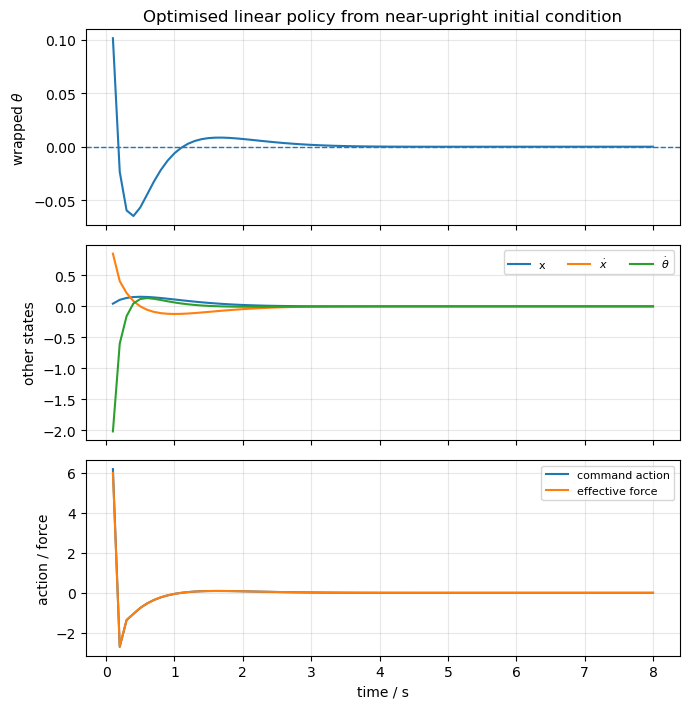

,time,x,x_dot,theta_wrapped,theta_dot,action,effective_force,point_loss
75,7.6,1.127576e-06,-1.104403e-06,-1.332522e-07,8.194920e-07,-1.215633e-06,-1.215633e-06,8.693046e-13
76,7.7,1.016079e-06,-1.131700e-06,-6.457671e-08,6.118625e-07,-5.336182e-07,-5.336182e-07,7.074341e-13
77,7.8,9.040542e-07,-1.114100e-06,-1.388283e-08,4.450086e-07,-3.369034e-08,-3.369034e-08,5.753176e-13
78,7.9,7.953103e-07,-1.065310e-06,2.243570e-08,3.124455e-07,3.211055e-07,3.211055e-07,4.647394e-13
79,8.0,6.924341e-07,-9.960450e-07,4.739915e-08,2.084668e-07,5.616489e-07,5.616489e-07,3.717027e-13


In [17]:
near_df = plot_policy_rollout(
    best_near.x,
    near_init,
    HORIZON_NEAR,
    near_sigmas,
    title="Optimised linear policy from near-upright initial condition",
    filename="task32_near_policy_rollout.png",
)
near_df.to_csv(LOG_DIR / "task32_near_policy_rollout.csv", index=False)

near_df.tail()

In [19]:
down_init = np.array([0.0, 0.0, np.pi, 0.0])

# Wider sigmas make the far-from-target region less completely saturated.
down_sigmas = np.array([2.0, 4.0, 1.0, 6.0])

best_down, down_runs = optimise_policy(
    down_init,
    horizon=HORIZON_DOWN,
    sigmas=down_sigmas,
    seed=SEED + 2,
    random_restarts=RANDOM_RESTARTS + 2,
    maxiter=MAXITER,
)

down_runs.to_csv(LOG_DIR / "task32_downward_policy_restarts.csv", index=False)
display(down_runs.head(8))
print("Best downward-start policy:", best_down.x)
print("Best downward-start loss:", best_down.fun)

,restart,success,loss,p_x,p_x_dot,p_theta,p_theta_dot,message
13,13,True,0.119695,6.232871,9.499954,31.989489,7.766004,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
1,1,True,0.124920,-0.218947,0.333951,11.580292,2.707142,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
3,3,False,0.168851,0.142085,1.250776,30.375564,3.183475,STOP: TOTAL NO. of ITERATIONS REACHED LIMIT
7,7,True,0.977523,13.285017,8.818891,46.734160,-16.417216,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
8,8,True,0.992080,-12.763989,-1.283009,-1.379762,-8.359048,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
9,9,True,0.992343,5.858464,-5.536464,-16.327318,1.046073,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
2,2,True,0.992364,-0.113275,-0.250236,28.122695,3.560030,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
10,10,True,0.992649,6.799180,-11.975832,11.813548,-10.531310,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


Best downward-start policy: [ 6.23287071  9.49995371 31.98948887  7.76600442]
Best downward-start loss: 0.11969467283509291


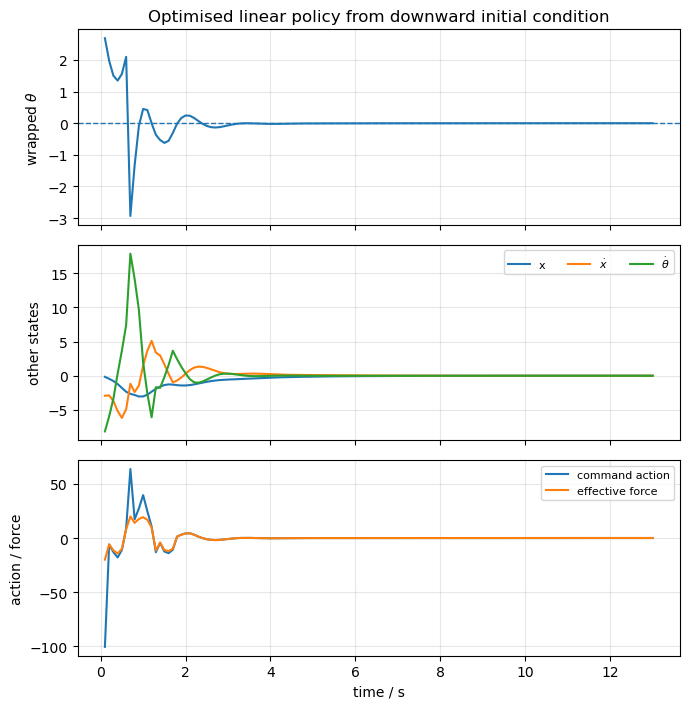

,time,x,x_dot,theta_wrapped,theta_dot,action,effective_force,point_loss
125,12.6,-0.000398,0.000300,-0.000024,0.000027,-0.000272,-0.000272,2.291407e-08
126,12.7,-0.000369,0.000284,-0.000022,0.000009,-0.000187,-0.000187,1.976770e-08
127,12.8,-0.000342,0.000257,-0.000021,0.000027,-0.000249,-0.000249,1.688392e-08
128,12.9,-0.000317,0.000245,-0.000019,0.000003,-0.000144,-0.000144,1.460147e-08
129,13.0,-0.000294,0.000219,-0.000018,0.000028,-0.000233,-0.000233,1.243444e-08


In [20]:
down_df = plot_policy_rollout(
    best_down.x,
    down_init,
    HORIZON_DOWN,
    down_sigmas,
    title="Optimised linear policy from downward initial condition",
    filename="task32_downward_policy_rollout.png",
)
down_df.to_csv(LOG_DIR / "task32_downward_policy_rollout.csv", index=False)

down_df.tail()

In [22]:
summary = pd.DataFrame([
    {
        "case": "near_upright",
        "initial_state": near_init.tolist(),
        "horizon_steps": HORIZON_NEAR,
        "horizon_seconds": HORIZON_NEAR * DELTA_TIME,
        "sigmas": near_sigmas.tolist(),
        "loss": float(best_near.fun),
        "p_x": best_near.x[0],
        "p_x_dot": best_near.x[1],
        "p_theta": best_near.x[2],
        "p_theta_dot": best_near.x[3],
    },
    {
        "case": "downward",
        "initial_state": down_init.tolist(),
        "horizon_steps": HORIZON_DOWN,
        "horizon_seconds": HORIZON_DOWN * DELTA_TIME,
        "sigmas": down_sigmas.tolist(),
        "loss": float(best_down.fun),
        "p_x": best_down.x[0],
        "p_x_dot": best_down.x[1],
        "p_theta": best_down.x[2],
        "p_theta_dot": best_down.x[3],
    },
])
summary.to_csv(LOG_DIR / "task32_policy_summary.csv", index=False)
display(summary)

,case,initial_state,horizon_steps,horizon_seconds,sigmas,loss,p_x,p_x_dot,p_theta,p_theta_dot
0,near_upright,"[0.0, 0.0, 0.2, 0.0]",80,8.0,"[1.0, 2.0, 0.45, 3.0]",0.006228,4.181541,4.699911,30.925735,4.957821
1,downward,"[0.0, 0.0, 3.141592653589793, 0.0]",130,13.0,"[2.0, 4.0, 1.0, 6.0]",0.119695,6.232871,9.499954,31.989489,7.766004


In [60]:
# Alternative downward initial condition: slightly away from -pi
down_init_minus_pi = np.array([0.0, 0.0, -np.pi + 1.1, 0.0])

print("Original down_init:", down_init)
print("Alternative down_init_minus_pi:", down_init_minus_pi)
print("wrapped original theta:", float(wrap_angle(jnp.asarray(down_init[2]))))
print("wrapped alternative theta:", float(wrap_angle(jnp.asarray(down_init_minus_pi[2]))))

# Re-optimise the policy for the alternative initial condition
best_down_minus_pi, down_runs_minus_pi = optimise_policy(
    down_init_minus_pi,
    horizon=HORIZON_DOWN,
    sigmas=down_sigmas,
    seed=SEED + 22,
    random_restarts=RANDOM_RESTARTS + 2,
    maxiter=MAXITER,
)

down_runs_minus_pi.to_csv(
    LOG_DIR / "task32_downward_policy_restarts_minus_pi_plus_1p1.csv",
    index=False,
)

display(down_runs_minus_pi.head(8))
print("Best downward-start policy (-pi + 1.1):", best_down_minus_pi.x)
print("Best downward-start loss (-pi + 1.1):", best_down_minus_pi.fun)

Original down_init: [0.         0.         3.14159265 0.        ]
Alternative down_init_minus_pi: [ 0.          0.         -2.04159265  0.        ]
wrapped original theta: -3.141592653589793
wrapped alternative theta: -2.041592653589793


,restart,success,loss,p_x,p_x_dot,p_theta,p_theta_dot,message
3,3,False,0.112187,1.675100,3.767948,37.587721,3.936127,STOP: TOTAL NO. of ITERATIONS REACHED LIMIT
0,0,False,0.572386,-0.002459,0.028292,0.047766,0.266427,ABNORMAL_TERMINATION_IN_LNSRCH
11,11,True,0.839098,-14.178453,-2.646020,-11.631876,-0.607553,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
2,2,True,0.946535,-0.147417,-0.534905,28.267854,3.055999,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
7,7,True,0.976575,-4.362512,-60.000000,-2.773632,-37.542741,CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
15,15,True,0.976756,7.823390,0.173357,19.831008,-4.534675,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
1,1,True,0.984738,0.002704,-0.045879,12.010963,1.864358,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
9,9,True,0.986161,-10.754999,0.905636,-23.561659,11.603091,CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


Best downward-start policy (-pi + 1.1): [ 1.67510007  3.76794828 37.58772084  3.93612697]
Best downward-start loss (-pi + 1.1): 0.11218652264059437


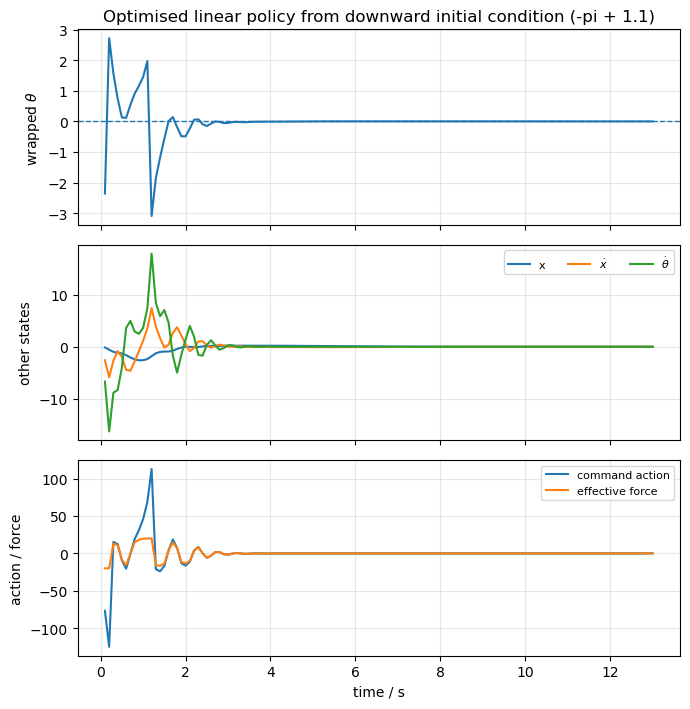

,time,x,x_dot,theta_wrapped,theta_dot,action,effective_force,point_loss
125,12.6,-0.000390,0.000114,0.000011,-0.000024,0.000113,0.000113,1.951104e-08
126,12.7,-0.000378,0.000123,0.000009,-0.000022,0.000091,0.000091,1.841222e-08
127,12.8,-0.000366,0.000130,0.000007,-0.000019,0.000071,0.000071,1.727349e-08
128,12.9,-0.000353,0.000135,0.000005,-0.000017,0.000053,0.000053,1.611635e-08
129,13.0,-0.000339,0.000138,0.000003,-0.000015,0.000037,0.000037,1.495938e-08


In [61]:
down_df_minus_pi = plot_policy_rollout(
    best_down_minus_pi.x,
    down_init_minus_pi,
    HORIZON_DOWN,
    down_sigmas,
    title="Optimised linear policy from downward initial condition (-pi + 1.1)",
    filename="task32_downward_policy_rollout_minus_pi_plus_1p1.png",
)

down_df_minus_pi.to_csv(
    LOG_DIR / "task32_downward_policy_rollout_minus_pi_plus_1p1.csv",
    index=False,
)

down_df_minus_pi.tail()

In [62]:
summary_with_alt = pd.DataFrame([
    {
        "case": "near_upright",
        "initial_state": near_init.tolist(),
        "horizon_steps": HORIZON_NEAR,
        "horizon_seconds": HORIZON_NEAR * DELTA_TIME,
        "sigmas": near_sigmas.tolist(),
        "loss": float(best_near.fun),
        "p_x": best_near.x[0],
        "p_x_dot": best_near.x[1],
        "p_theta": best_near.x[2],
        "p_theta_dot": best_near.x[3],
    },
    {
        "case": "downward_pi",
        "initial_state": down_init.tolist(),
        "horizon_steps": HORIZON_DOWN,
        "horizon_seconds": HORIZON_DOWN * DELTA_TIME,
        "sigmas": down_sigmas.tolist(),
        "loss": float(best_down.fun),
        "p_x": best_down.x[0],
        "p_x_dot": best_down.x[1],
        "p_theta": best_down.x[2],
        "p_theta_dot": best_down.x[3],
    },
    {
        "case": "downward_minus_pi_plus_0p1",
        "initial_state": down_init_minus_pi.tolist(),
        "horizon_steps": HORIZON_DOWN,
        "horizon_seconds": HORIZON_DOWN * DELTA_TIME,
        "sigmas": down_sigmas.tolist(),
        "loss": float(best_down_minus_pi.fun),
        "p_x": best_down_minus_pi.x[0],
        "p_x_dot": best_down_minus_pi.x[1],
        "p_theta": best_down_minus_pi.x[2],
        "p_theta_dot": best_down_minus_pi.x[3],
    },
])

summary_with_alt.to_csv(LOG_DIR / "task32_policy_summary_with_alt_downward.csv", index=False)
display(summary_with_alt)

,case,initial_state,horizon_steps,horizon_seconds,sigmas,loss,p_x,p_x_dot,p_theta,p_theta_dot
0,near_upright,"[0.0, 0.0, 0.2, 0.0]",80,8.0,"[1.0, 2.0, 0.45, 3.0]",0.006228,4.181541,4.699911,30.925735,4.957821
1,downward_pi,"[0.0, 0.0, 3.141592653589793, 0.0]",130,13.0,"[2.0, 4.0, 1.0, 6.0]",0.119695,6.232871,9.499954,31.989489,7.766004
2,downward_minus_pi_plus_0p1,"[0.0, 0.0, -2.041592653589793, 0.0]",130,13.0,"[2.0, 4.0, 1.0, 6.0]",0.112187,1.675100,3.767948,37.587721,3.936127


In [66]:

# --- Linear-algebra policy probe: helper functions ---
# This cell constructs a pseudo-supervised target action u_star for sampled states.
# For each sampled state, it scans candidate actions and chooses the one that minimises
# the one-step loss after a single true-dynamics step.

def wrap_angle_np(theta):
    return (np.asarray(theta) + np.pi) % (2.0 * np.pi) - np.pi


def policy_features_np(states):
    states = np.asarray(states, dtype=float)
    return np.column_stack([
        states[:, 0],
        states[:, 1],
        wrap_angle_np(states[:, 2]),
        states[:, 3],
    ])


def sample_state_cloud(init_state, n, scales, seed=0):
    """Sample states around an initial condition / operating region."""
    rng_local = np.random.default_rng(seed)
    init_state = np.asarray(init_state, dtype=float)
    scales = np.asarray(scales, dtype=float)
    states = init_state + rng_local.normal(0.0, scales, size=(n, 4))
    states[:, 2] = wrap_angle_np(states[:, 2])
    return states


def make_greedy_action_function(action_grid):
    """Return a vectorised JAX function mapping states -> one-step greedy actions."""
    action_grid_j = jnp.asarray(action_grid, dtype=jnp.float64)

    def loss_for_one_state(state, sigmas_j, effort_weight):
        def loss_for_action(action):
            next_state = cartpole_step_jax(state, action)
            force_fraction = jnp.tanh(action / MAX_FORCE)
            return point_loss(next_state, sigmas_j) + effort_weight * force_fraction**2
        losses = jax.vmap(loss_for_action)(action_grid_j)
        idx = jnp.argmin(losses)
        return action_grid_j[idx], losses[idx]

    @jax.jit
    def greedy_actions(states_j, sigmas_j, effort_weight=0.002):
        return jax.vmap(lambda s: loss_for_one_state(s, sigmas_j, effort_weight))(states_j)

    return greedy_actions


def fit_linear_policy_from_actions(states, target_actions, ridge=1e-4):
    """Solve min_p ||Phi p - u_star||^2 + ridge ||p||^2."""
    Phi = policy_features_np(states)
    target_actions = np.asarray(target_actions, dtype=float)
    A = Phi.T @ Phi + ridge * np.eye(Phi.shape[1])
    b = Phi.T @ target_actions
    p = np.linalg.solve(A, b)
    pred_actions = Phi @ p
    return p, {
        "Phi_shape": Phi.shape,
        "condition_number_PhiTPhi": float(np.linalg.cond(Phi.T @ Phi)),
        "target_action_rmse": float(np.sqrt(np.mean((pred_actions - target_actions)**2))),
        "max_abs_pred_action": float(np.max(np.abs(pred_actions))),
        "mean_abs_target_action": float(np.mean(np.abs(target_actions))),
    }, pred_actions


,case,method,trajectory_loss,direct_policy_search_loss,p_x,p_x_dot,p_theta,p_theta_dot,Phi_shape,condition_number_PhiTPhi,target_action_rmse,max_abs_pred_action,mean_abs_target_action
0,near_upright,one_step_greedy_then_linear_solve,0.900482,0.006228,-0.29955,-1.31252,14.044319,2.657932,"(300, 4)",11.998981,1.858018,25.881093,5.298333


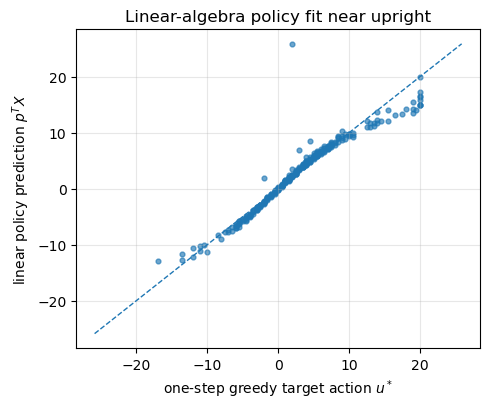

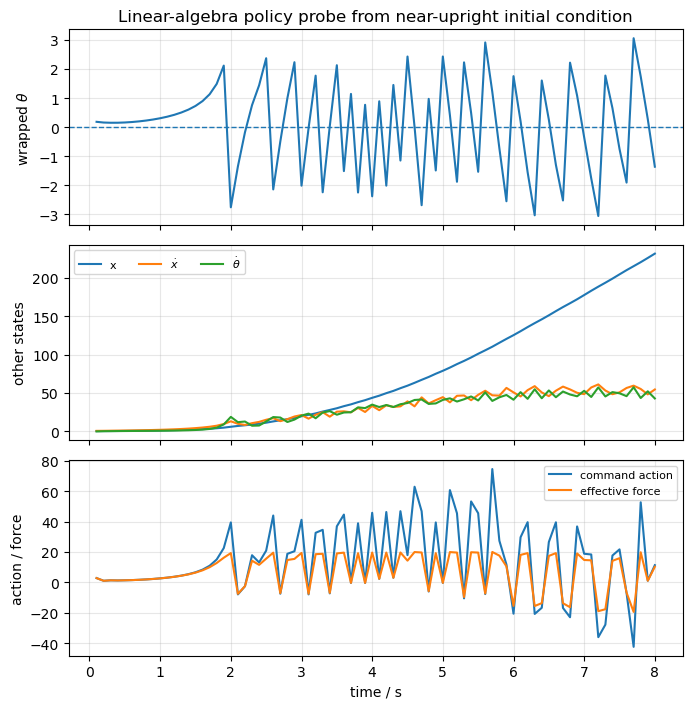

In [68]:

# --- Near-upright linear-algebra baseline ---
# This gives a concrete answer to: "What if we try to get p from X and u by linear algebra?"

ACTION_GRID = np.linspace(-20.0, 20.0, 81)
greedy_action_fn = make_greedy_action_function(ACTION_GRID)

N_GREEDY = 300 if RUN_MODE == "full" else 120
near_cloud_scales = np.array([0.6, 1.0, 0.35, 1.5])
near_states_cloud = sample_state_cloud(
    near_init,
    n=N_GREEDY,
    scales=near_cloud_scales,
    seed=SEED + 900,
)

u_star_near_j, one_step_loss_near_j = greedy_action_fn(
    jnp.asarray(near_states_cloud, dtype=jnp.float64),
    jnp.asarray(near_sigmas, dtype=jnp.float64),
)
u_star_near = np.asarray(u_star_near_j)
one_step_loss_near = np.asarray(one_step_loss_near_j)

p_linalg_near, diag_near, u_fit_near = fit_linear_policy_from_actions(
    near_states_cloud,
    u_star_near,
    ridge=1e-4,
)

loss_linalg_near = float(loss_value(
    jnp.asarray(p_linalg_near, dtype=jnp.float64),
    jnp.asarray(near_init, dtype=jnp.float64),
    HORIZON_NEAR,
    jnp.asarray(near_sigmas, dtype=jnp.float64),
))

loss_direct_near = float(best_near.fun) if "best_near" in globals() else np.nan

near_probe_summary = pd.DataFrame([{
    "case": "near_upright",
    "method": "one_step_greedy_then_linear_solve",
    "trajectory_loss": loss_linalg_near,
    "direct_policy_search_loss": loss_direct_near,
    "p_x": p_linalg_near[0],
    "p_x_dot": p_linalg_near[1],
    "p_theta": p_linalg_near[2],
    "p_theta_dot": p_linalg_near[3],
    **diag_near,
}])

near_probe_summary.to_csv(LOG_DIR / "task32_linalg_policy_probe_near_summary.csv", index=False)
display(near_probe_summary)

fig, ax = plt.subplots(figsize=(5.0, 4.2))
ax.scatter(u_star_near, u_fit_near, s=12, alpha=0.65)
lim = max(1.0, np.max(np.abs(np.r_[u_star_near, u_fit_near])))
ax.plot([-lim, lim], [-lim, lim], linestyle="--", linewidth=1)
ax.set_xlabel("one-step greedy target action $u^*$")
ax.set_ylabel("linear policy prediction $p^T X$")
ax.set_title("Linear-algebra policy fit near upright")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "task32_linalg_policy_near_action_fit.png", dpi=180)
plt.show()

# Plot rollout of the linear-algebra policy under the true dynamics.
near_linalg_df = plot_policy_rollout(
    p_linalg_near,
    near_init,
    HORIZON_NEAR,
    near_sigmas,
    title="Linear-algebra policy probe from near-upright initial condition",
    filename="task32_linalg_policy_near_rollout.png",
)
near_linalg_df.to_csv(LOG_DIR / "task32_linalg_policy_near_rollout.csv", index=False)


,case,method,trajectory_loss,direct_policy_search_loss,p_x,p_x_dot,p_theta,p_theta_dot,Phi_shape,condition_number_PhiTPhi,target_action_rmse,max_abs_pred_action,mean_abs_target_action
0,downward,one_step_greedy_then_linear_solve,0.881965,0.119695,-0.554044,-2.835139,-4.638042,-0.679201,"(350, 4)",10.874667,7.76299,23.84234,14.157143


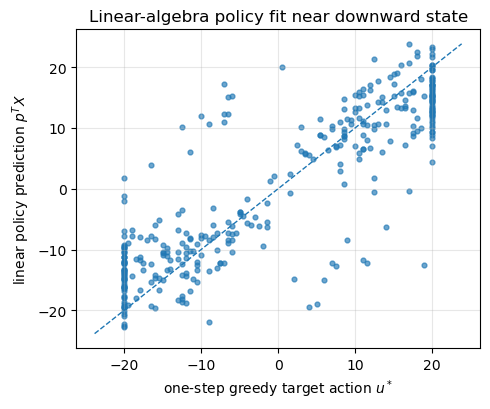

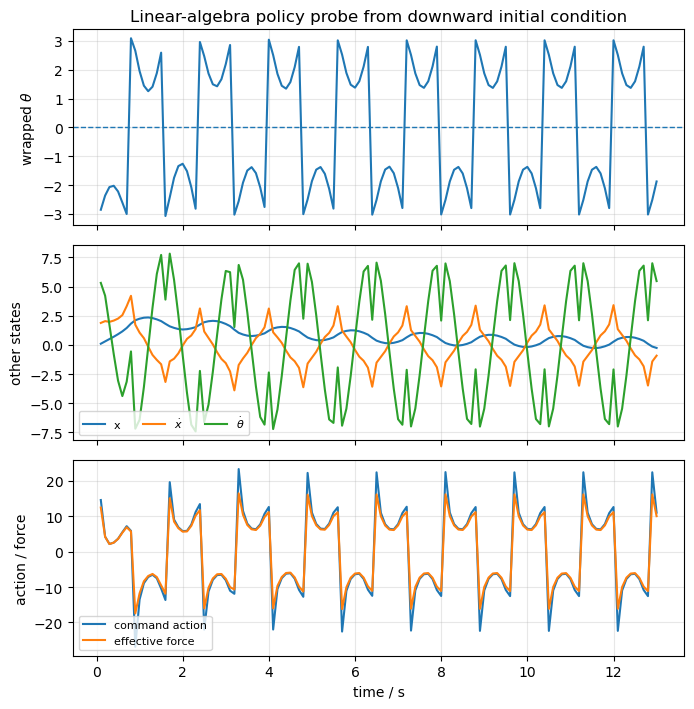

In [70]:

# --- Optional downward linear-algebra baseline ---
# This usually performs worse than the direct trajectory optimiser because one-step greedy labels
# do not encode the long-horizon swing-up strategy.

if "down_init" in globals() and "down_sigmas" in globals():
    N_GREEDY_DOWN = 350 if RUN_MODE == "full" else 140
    down_cloud_scales = np.array([0.8, 1.5, 0.7, 2.5])
    down_states_cloud = sample_state_cloud(
        down_init,
        n=N_GREEDY_DOWN,
        scales=down_cloud_scales,
        seed=SEED + 901,
    )

    u_star_down_j, one_step_loss_down_j = greedy_action_fn(
        jnp.asarray(down_states_cloud, dtype=jnp.float64),
        jnp.asarray(down_sigmas, dtype=jnp.float64),
    )
    u_star_down = np.asarray(u_star_down_j)
    one_step_loss_down = np.asarray(one_step_loss_down_j)

    p_linalg_down, diag_down, u_fit_down = fit_linear_policy_from_actions(
        down_states_cloud,
        u_star_down,
        ridge=1e-4,
    )

    loss_linalg_down = float(loss_value(
        jnp.asarray(p_linalg_down, dtype=jnp.float64),
        jnp.asarray(down_init, dtype=jnp.float64),
        HORIZON_DOWN,
        jnp.asarray(down_sigmas, dtype=jnp.float64),
    ))
    loss_direct_down = float(best_down.fun) if "best_down" in globals() else np.nan

    down_probe_summary = pd.DataFrame([{
        "case": "downward",
        "method": "one_step_greedy_then_linear_solve",
        "trajectory_loss": loss_linalg_down,
        "direct_policy_search_loss": loss_direct_down,
        "p_x": p_linalg_down[0],
        "p_x_dot": p_linalg_down[1],
        "p_theta": p_linalg_down[2],
        "p_theta_dot": p_linalg_down[3],
        **diag_down,
    }])

    down_probe_summary.to_csv(LOG_DIR / "task32_linalg_policy_probe_down_summary.csv", index=False)
    display(down_probe_summary)

    fig, ax = plt.subplots(figsize=(5.0, 4.2))
    ax.scatter(u_star_down, u_fit_down, s=12, alpha=0.65)
    lim = max(1.0, np.max(np.abs(np.r_[u_star_down, u_fit_down])))
    ax.plot([-lim, lim], [-lim, lim], linestyle="--", linewidth=1)
    ax.set_xlabel("one-step greedy target action $u^*$")
    ax.set_ylabel("linear policy prediction $p^T X$")
    ax.set_title("Linear-algebra policy fit near downward state")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "task32_linalg_policy_down_action_fit.png", dpi=180)
    plt.show()

    down_linalg_df = plot_policy_rollout(
        p_linalg_down,
        down_init,
        HORIZON_DOWN,
        down_sigmas,
        title="Linear-algebra policy probe from downward initial condition",
        filename="task32_linalg_policy_down_rollout.png",
    )
    down_linalg_df.to_csv(LOG_DIR / "task32_linalg_policy_down_rollout.csv", index=False)
else:
    print("Run the downward Task 3.2 cells first if you want the downward linear-algebra probe.")


In [72]:

# --- Combined summary for report use ---
# This saves a compact table if both near and downward probes have been run.

summary_parts = []
if "near_probe_summary" in globals():
    summary_parts.append(near_probe_summary)
if "down_probe_summary" in globals():
    summary_parts.append(down_probe_summary)

if summary_parts:
    linalg_probe_summary = pd.concat(summary_parts, ignore_index=True)
    linalg_probe_summary.to_csv(LOG_DIR / "task32_linalg_policy_probe_summary.csv", index=False)
    display(linalg_probe_summary)
else:
    print("No linear-algebra probe summaries found yet.")


,case,method,trajectory_loss,direct_policy_search_loss,p_x,p_x_dot,p_theta,p_theta_dot,Phi_shape,condition_number_PhiTPhi,target_action_rmse,max_abs_pred_action,mean_abs_target_action
0,near_upright,one_step_greedy_then_linear_solve,0.900482,0.006228,-0.299550,-1.312520,14.044319,2.657932,"(300, 4)",11.998981,1.858018,25.881093,5.298333
1,downward,one_step_greedy_then_linear_solve,0.881965,0.119695,-0.554044,-2.835139,-4.638042,-0.679201,"(350, 4)",10.874667,7.762990,23.842340,14.157143
